In [6]:
# CELL 1: Setup
import sys
sys.path.append('..')
 
import os
import cv2
import copy
import json
import torch
import numpy as np
import random
import nibabel as nib
import matplotlib.pyplot as plt
from torch.nn import CrossEntropyLoss
import segmentation_models_pytorch as smp
 
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
 
# ── CONFIGURE THIS ──
PEDS_DATA_PATH = '../PKG - BraTS-PEDs-v1/BraTS-PEDs-v1/Training'
N_EPISODES = 200
IMG_SIZE = 128
VOLUME_START = 22
VOLUME_SLICES = 100
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
 
# Verify pediatric data exists
peds_patients = sorted([
    d for d in os.listdir(PEDS_DATA_PATH)
    if os.path.isdir(os.path.join(PEDS_DATA_PATH, d))
])
print(f"✓ Device: {DEVICE}")
print(f"✓ BraTS-PEDs patients found: {len(peds_patients)}")
print(f"  First 3: {peds_patients[:3]}")

✓ Device: mps
✓ BraTS-PEDs patients found: 257
  First 3: ['BraTS-PED-00001-000', 'BraTS-PED-00002-000', 'BraTS-PED-00003-000']


In [7]:
# CELL 2: Verify BraTS-PEDs Format
print("=" * 60)
print("STEP 1: Verify BraTS-PEDs data format")
print("=" * 60)
 
print(f"\nTotal pediatric patients: {len(peds_patients)}")
print(f"First 5 patient IDs: {peds_patients[:5]}")
 
# Check file naming in one patient
sample_patient = peds_patients[0]
sample_path = os.path.join(PEDS_DATA_PATH, sample_patient)
print(f"\nFiles in {sample_patient}:")
for f in sorted(os.listdir(sample_path)):
    print(f"  {f}")
 
 
def find_file(path, keywords):
    """Find a file matching any of the keywords."""
    for f in os.listdir(path):
        f_lower = f.lower()
        for kw in keywords:
            if kw in f_lower:
                return os.path.join(path, f)
    return None
 
 
flair_path = find_file(sample_path, ['t2f', 'flair', 't2-f'])
t1ce_path = find_file(sample_path, ['t1c', 't1ce', 't1-c'])
seg_path = find_file(sample_path, ['seg'])
 
print(f"\nFLAIR file: {os.path.basename(flair_path) if flair_path else 'NOT FOUND'}")
print(f"T1CE file:  {os.path.basename(t1ce_path) if t1ce_path else 'NOT FOUND'}")
print(f"Seg file:   {os.path.basename(seg_path) if seg_path else 'NOT FOUND'}")
 
if flair_path and t1ce_path and seg_path:
    flair_vol = nib.load(flair_path).get_fdata()
    t1ce_vol = nib.load(t1ce_path).get_fdata()
    seg_vol = nib.load(seg_path).get_fdata()
 
    print(f"\nFLAIR shape: {flair_vol.shape}")
    print(f"T1CE shape:  {t1ce_vol.shape}")
    print(f"Seg shape:   {seg_vol.shape}")
    print(f"Seg unique labels: {np.unique(seg_vol).astype(int)}")
    print(f"Seg label counts:")
    for label in np.unique(seg_vol).astype(int):
        count = np.sum(seg_vol == label)
        print(f"  Label {label}: {count} voxels ({count/seg_vol.size*100:.2f}%)")
else:
    print("\n⚠ Could not find all required files!")
    print("Update the keywords in find_file() to match your naming convention.")

STEP 1: Verify BraTS-PEDs data format

Total pediatric patients: 257
First 5 patient IDs: ['BraTS-PED-00001-000', 'BraTS-PED-00002-000', 'BraTS-PED-00003-000', 'BraTS-PED-00004-000', 'BraTS-PED-00005-000']

Files in BraTS-PED-00001-000:
  BraTS-PED-00001-000-seg.nii.gz
  BraTS-PED-00001-000-t1c.nii.gz
  BraTS-PED-00001-000-t1n.nii.gz
  BraTS-PED-00001-000-t2f.nii.gz
  BraTS-PED-00001-000-t2w.nii.gz

FLAIR file: BraTS-PED-00001-000-t2f.nii.gz
T1CE file:  BraTS-PED-00001-000-t1c.nii.gz
Seg file:   BraTS-PED-00001-000-seg.nii.gz

FLAIR shape: (240, 240, 155)
T1CE shape:  (240, 240, 155)
Seg shape:   (240, 240, 155)
Seg unique labels: [0 1 2 3 4]
Seg label counts:
  Label 0: 8799333 voxels (98.56%)
  Label 1: 6204 voxels (0.07%)
  Label 2: 87311 voxels (0.98%)
  Label 3: 607 voxels (0.01%)
  Label 4: 34545 voxels (0.39%)


In [8]:
# CELL 3: Build BraTS-PEDs Data Loader
def find_modality_file(patient_path, modality):
    """Find the file for a given modality in a patient folder."""
    keywords = {
        'flair': ['t2f', 'flair', 't2-f'],
        't1ce': ['t1c', 't1ce', 't1-c'],
        'seg': ['seg'],
    }
    for f in os.listdir(patient_path):
        f_lower = f.lower()
        for kw in keywords[modality]:
            if kw in f_lower:
                return os.path.join(patient_path, f)
    return None
 
 
def load_peds_patient_slices(patient_id, data_path):
    """
    Load all tumor-containing slices from a BraTS-PEDs patient.
    Uses same slice range as BraTS 2020 (slices 22-122) for fair comparison.
    Returns images (N,2,H,W) and masks (N,H,W) as numpy arrays.
    """
    path = os.path.join(data_path, patient_id)
 
    flair_path = find_modality_file(path, 'flair')
    t1ce_path = find_modality_file(path, 't1ce')
    seg_path = find_modality_file(path, 'seg')
 
    if not all([flair_path, t1ce_path, seg_path]):
        print(f"  ⚠ Missing files for {patient_id}, skipping")
        return np.array([]), np.array([])
 
    flair = nib.load(flair_path).get_fdata()
    t1ce = nib.load(t1ce_path).get_fdata()
    seg = nib.load(seg_path).get_fdata()
 
    images, masks = [], []
 
    for s in range(VOLUME_SLICES):
        sl = s + VOLUME_START
        if sl >= flair.shape[2]:
            continue
 
        fl = cv2.resize(flair[:, :, sl], (IMG_SIZE, IMG_SIZE))
        t1 = cv2.resize(t1ce[:, :, sl], (IMG_SIZE, IMG_SIZE))
        sg = cv2.resize(seg[:, :, sl], (IMG_SIZE, IMG_SIZE),
                        interpolation=cv2.INTER_NEAREST)
 
        img = np.stack([fl, t1], axis=0)  # (2, H, W)
        mx = img.max()
        if mx > 0:
            img = img / mx
 
        # Remap label 4 → 3 (same as BraTS 2020)
        sg[sg == 4] = 3
 
        # Only keep slices with tumor
        if sg.max() > 0:
            images.append(img)
            masks.append(sg)
 
    if len(images) == 0:
        return np.array([]), np.array([])
 
    return np.stack(images), np.stack(masks)
 
 
# Quick test
print("Testing loader on first patient...")
test_imgs, test_masks = load_peds_patient_slices(peds_patients[0], PEDS_DATA_PATH)
if len(test_imgs) > 0:
    print(f"✓ Loaded {len(test_imgs)} tumor slices")
    print(f"  Images shape: {test_imgs.shape}")
    print(f"  Masks shape:  {test_masks.shape}")
    print(f"  Mask labels:  {np.unique(test_masks).astype(int)}")
else:
    print("⚠ No tumor slices found — check the loader")

Testing loader on first patient...
✓ Loaded 89 tumor slices
  Images shape: (89, 2, 128, 128)
  Masks shape:  (89, 128, 128)
  Mask labels:  [0 1 2 3]


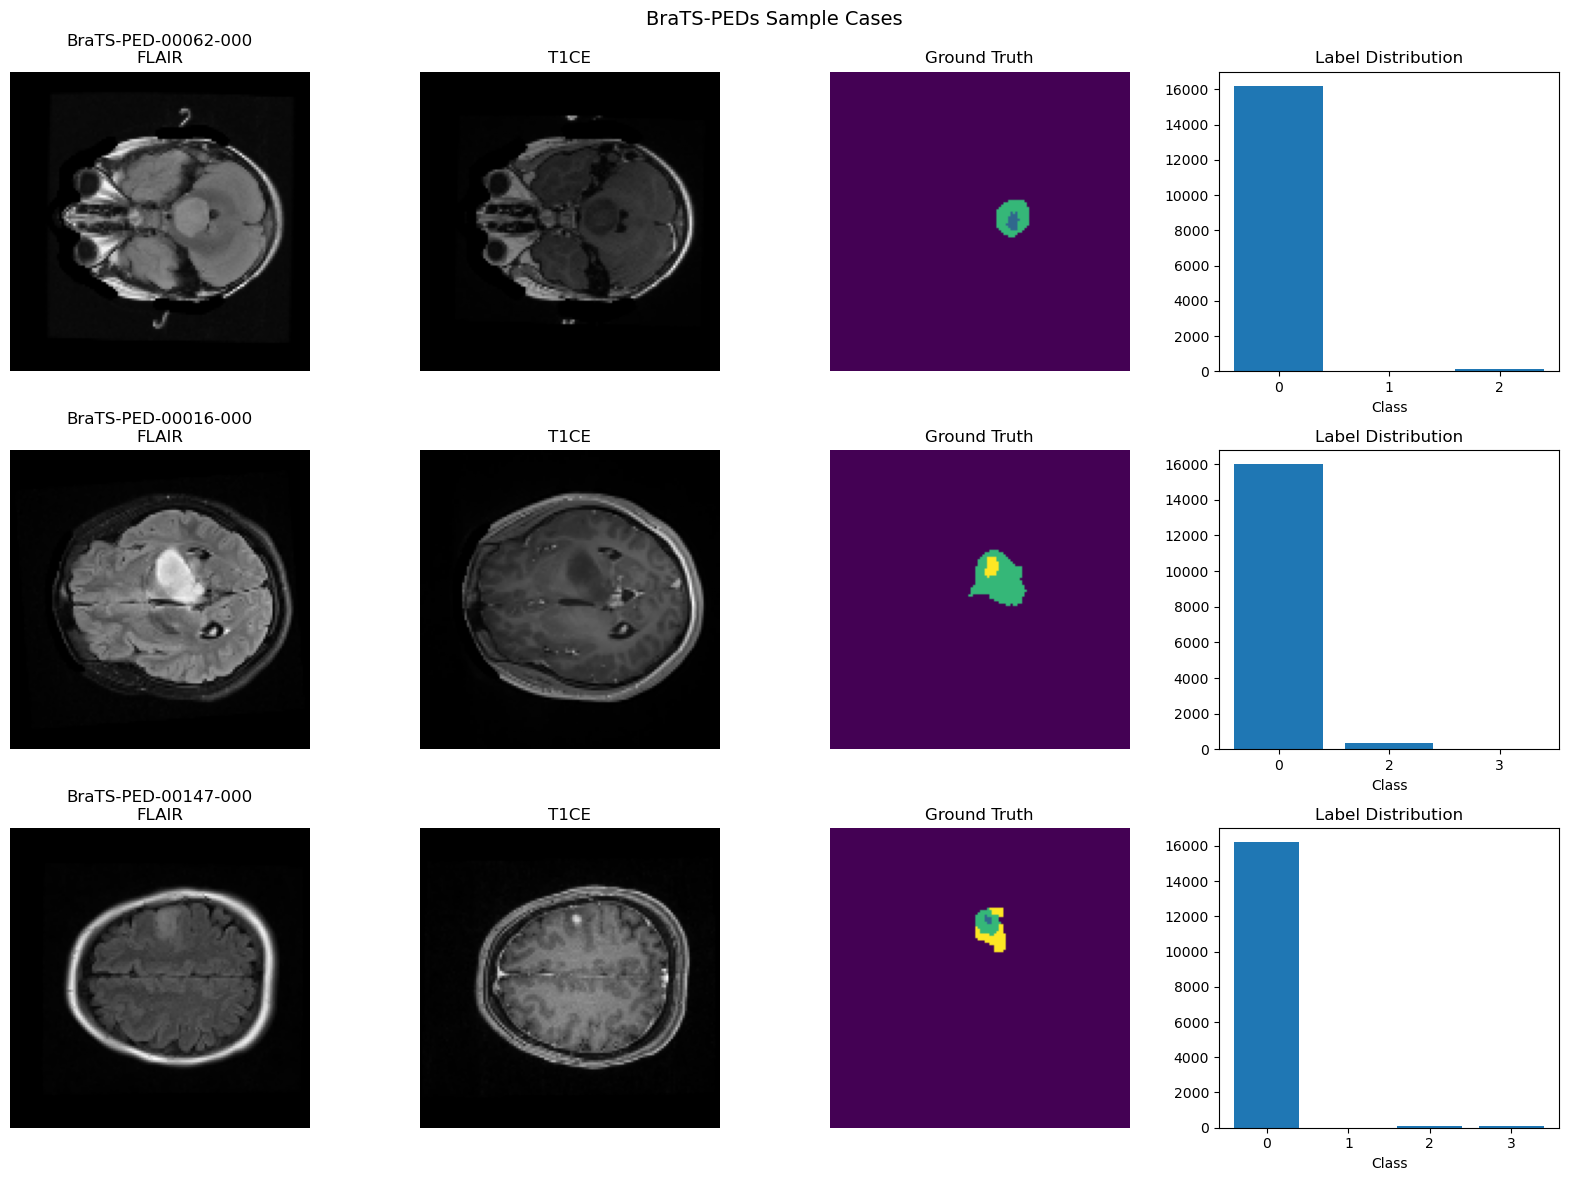

In [9]:
# CELL 4: Visualize Sample Pediatric Cases
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
 
for row in range(3):
    pid = random.choice(peds_patients)
    imgs, msks = load_peds_patient_slices(pid, PEDS_DATA_PATH)
    if len(imgs) == 0:
        continue
 
    idx = len(imgs) // 2
 
    axes[row, 0].imshow(imgs[idx, 0], cmap='gray')
    axes[row, 0].set_title(f'{pid}\nFLAIR')
    axes[row, 0].axis('off')
 
    axes[row, 1].imshow(imgs[idx, 1], cmap='gray')
    axes[row, 1].set_title('T1CE')
    axes[row, 1].axis('off')
 
    axes[row, 2].imshow(msks[idx], cmap='viridis', vmin=0, vmax=3)
    axes[row, 2].set_title('Ground Truth')
    axes[row, 2].axis('off')
 
    labels, counts = np.unique(msks[idx], return_counts=True)
    axes[row, 3].bar([str(int(l)) for l in labels], counts)
    axes[row, 3].set_title('Label Distribution')
    axes[row, 3].set_xlabel('Class')
 
plt.suptitle('BraTS-PEDs Sample Cases', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join('../results', 'peds_sample_cases.png'), dpi=150)
plt.show()

In [10]:
# CELL 5: Build Cross-Tumor Index
from configs.config import Config
from configs.metrics import dice_score, hd95_multiclass
from configs.results_utils import save_kshot_results
from configs.model_utils import load_model_weights
from data.splits import get_patient_splits
from data.few_shot_sampler import load_patient_slices, has_tumor
from models.bu_net import BUNet
from models.prototypical_segmentation import PrototypicalSegmentation
from models.maml_segmentation import MAMLSegmentation
 
Config.create_dirs()
 
print("=" * 60)
print("STEP 2: Building query and support indices")
print("=" * 60)
 
# Build pediatric query index
print("\nBuilding BraTS-PEDs query index...")
peds_index = []
valid_patients = 0
skipped_patients = 0
 
for pid in peds_patients:
    imgs, msks = load_peds_patient_slices(pid, PEDS_DATA_PATH)
    if len(imgs) == 0:
        skipped_patients += 1
        continue
    valid_patients += 1
    for img, msk in zip(imgs, msks):
        peds_index.append((img, msk))
 
print(f"✓ Valid patients:   {valid_patients}")
print(f"  Skipped patients: {skipped_patients}")
print(f"  Total query slices: {len(peds_index)}")
 
# Build BraTS 2020 support index
_, val_ids, _ = get_patient_splits(Config.TRAIN_DATASET_PATH)
 
print(f"\nBuilding BraTS 2020 support index from {len(val_ids)} val patients...")
support_index = []
for pid in val_ids:
    imgs, msks = load_patient_slices(pid, Config.TRAIN_DATASET_PATH)
    for img, msk in zip(imgs, msks):
        if has_tumor(msk):
            support_index.append((img, msk))
 
print(f"✓ Support slices: {len(support_index)}")

STEP 2: Building query and support indices

Building BraTS-PEDs query index...
✓ Valid patients:   257
  Skipped patients: 0
  Total query slices: 11642
✓ Splits -> Train: 258, Val: 74, Test: 37

Building BraTS 2020 support index from 74 val patients...
✓ Support slices: 4544


In [11]:
# CELL 6: Cross-Tumor Episode Sampler
class CrossTumorSampler:
    """
    Samples episodes with:
      - Support from BraTS 2020 (adult, in-distribution)
      - Query from BraTS-PEDs (pediatric, out-of-distribution)
    """
 
    def __init__(self, support_index, query_index, k_shot=5, n_query=10):
        self.support_index = support_index
        self.query_index = query_index
        self.k_shot = k_shot
        self.n_query = n_query
 
    def _to_tensors(self, items):
        imgs = torch.tensor(np.stack([x[0] for x in items]), dtype=torch.float32)
        masks = torch.tensor(np.stack([x[1] for x in items]), dtype=torch.long)
        return {'image': imgs, 'mask': masks}
 
    def sample_episode(self):
        support_items = random.sample(self.support_index,
                                      min(self.k_shot, len(self.support_index)))
        query_items = random.sample(self.query_index,
                                    min(self.n_query, len(self.query_index)))
        return self._to_tensors(support_items), self._to_tensors(query_items)
 
    def iter_episodes(self, n_episodes=100):
        for _ in range(n_episodes):
            yield self.sample_episode()
 
 
# Build samplers for each k
cross_samplers = {}
for k in Config.K_SHOT_VALUES:
    cross_samplers[k] = CrossTumorSampler(
        support_index=support_index,
        query_index=peds_index,
        k_shot=k,
        n_query=10,
    )
    print(f"✓ Cross-tumor sampler k={k}")

✓ Cross-tumor sampler k=1
✓ Cross-tumor sampler k=5
✓ Cross-tumor sampler k=10
✓ Cross-tumor sampler k=20


In [13]:
# CELL 7: Load All Three Models
print("Loading models...")

baseline_model = BUNet(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)
load_model_weights(baseline_model, Config.CHECKPOINT_DIR, 'best_model.pth', Config.DEVICE)
print("✓ Baseline loaded")

proto_model = PrototypicalSegmentation(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)
load_model_weights(proto_model, Config.CHECKPOINT_DIR, 'prototypical_ep1000.pth', Config.DEVICE)
print("✓ Prototypical loaded")

maml_model = MAMLSegmentation(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
)

# MAML checkpoint saves model.model.state_dict(), not the wrapper
maml_ckpt_path = os.path.join(Config.CHECKPOINT_DIR, 'maml_task1000.pth')
if os.path.exists(maml_ckpt_path):
    ckpt = torch.load(maml_ckpt_path, map_location=Config.DEVICE)
    if 'model_state_dict' in ckpt:
        maml_model.model.load_state_dict(ckpt['model_state_dict'])
    else:
        maml_model.load_state_dict(ckpt, strict=False)
    print(f"✓ Loaded MAML checkpoint: maml_task1000.pth")
else:
    print(f"⚠ MAML checkpoint not found at {maml_ckpt_path}")

maml_model = maml_model.to(Config.DEVICE)
print("✓ MAML loaded")

Loading models...
✓ Loaded checkpoint: best_model.pth
✓ Baseline loaded
✓ Loaded checkpoint: prototypical_ep1000.pth
✓ Prototypical loaded
✓ Loaded MAML checkpoint: maml_task1000.pth
✓ MAML loaded


In [14]:
# CELL 8: Evaluate Baseline — Cross-Tumor
print("=" * 60)
print("BASELINE: BraTS 2020 → BraTS-PEDs")
print("=" * 60)
 
ce = CrossEntropyLoss()
baseline_cross = {}
 
for k in Config.K_SHOT_VALUES:
    print(f"\nk={k}, {N_EPISODES} episodes...")
    episode_dice = []
    episode_hd95 = []
 
    for ep, (support, query) in enumerate(cross_samplers[k].iter_episodes(N_EPISODES)):
        model = copy.deepcopy(baseline_model).to(Config.DEVICE)
        opt = torch.optim.Adam(model.parameters(), lr=1e-4)
 
        # Fine-tune on support (BraTS 2020 adult)
        model.train()
        s_img = support['image'].to(Config.DEVICE)
        s_mask = support['mask'].to(Config.DEVICE)
        for _ in range(10):
            opt.zero_grad()
            loss = ce(model(s_img), s_mask)
            loss.backward()
            opt.step()
 
        # Evaluate on query (BraTS-PEDs pediatric)
        model.eval()
        q_img = query['image'].to(Config.DEVICE)
        q_mask = query['mask'].to(Config.DEVICE)
        with torch.no_grad():
            preds = torch.argmax(model(q_img), dim=1)
 
        d = dice_score(preds, q_mask)
        episode_dice.append(d['mean_tumor_dice'])
 
        hd = hd95_multiclass(preds, q_mask)
        episode_hd95.append(hd['mean_tumor_hd95'])
 
        if (ep + 1) % 50 == 0:
            print(f"  Episode {ep+1}/{N_EPISODES} | "
                  f"Dice: {np.mean(episode_dice):.4f} | "
                  f"HD95: {np.nanmean(episode_hd95):.2f}")
 
    baseline_cross[k] = {
        'mean': float(np.mean(episode_dice)),
        'std': float(np.std(episode_dice)),
        'hd95_mean': float(np.nanmean(episode_hd95)),
        'hd95_std': float(np.nanstd(episode_hd95)),
    }
    print(f"  ✓ k={k}: Dice={baseline_cross[k]['mean']:.4f} ± {baseline_cross[k]['std']:.4f} | "
          f"HD95={baseline_cross[k]['hd95_mean']:.2f} ± {baseline_cross[k]['hd95_std']:.2f}")
 
save_kshot_results(baseline_cross, Config.RESULTS_DIR, 'baseline_cross_tumor.json')

BASELINE: BraTS 2020 → BraTS-PEDs

k=1, 200 episodes...
  Episode 50/200 | Dice: 0.1434 | HD95: 16.81
  Episode 100/200 | Dice: 0.1465 | HD95: 16.65
  Episode 150/200 | Dice: 0.1464 | HD95: 17.35
  Episode 200/200 | Dice: 0.1430 | HD95: 17.18
  ✓ k=1: Dice=0.1430 ± 0.0674 | HD95=17.18 ± 12.57

k=5, 200 episodes...
  Episode 50/200 | Dice: 0.1532 | HD95: 8.51
  Episode 100/200 | Dice: 0.1570 | HD95: 8.63
  Episode 150/200 | Dice: 0.1597 | HD95: 8.39
  Episode 200/200 | Dice: 0.1578 | HD95: 8.22
  ✓ k=5: Dice=0.1578 ± 0.0632 | HD95=8.22 ± 3.16

k=10, 200 episodes...
  Episode 50/200 | Dice: 0.1533 | HD95: 7.85
  Episode 100/200 | Dice: 0.1610 | HD95: 7.78
  Episode 150/200 | Dice: 0.1652 | HD95: 7.80
  Episode 200/200 | Dice: 0.1681 | HD95: 7.77
  ✓ k=10: Dice=0.1681 ± 0.0650 | HD95=7.77 ± 2.59

k=20, 200 episodes...
  Episode 50/200 | Dice: 0.1667 | HD95: 7.98
  Episode 100/200 | Dice: 0.1625 | HD95: 8.01
  Episode 150/200 | Dice: 0.1653 | HD95: 7.96
  Episode 200/200 | Dice: 0.1679 | H

In [15]:
# CELL 9: Evaluate Prototypical — Cross-Tumor
print("=" * 60)
print("PROTOTYPICAL: BraTS 2020 → BraTS-PEDs")
print("=" * 60)
 
loss_fn = smp.losses.DiceLoss(mode='multiclass')
proto_cross = {}
proto_model.eval()
 
for k in Config.K_SHOT_VALUES:
    print(f"\nk={k}, {N_EPISODES} episodes...")
    episode_dice = []
    episode_hd95 = []
 
    for ep, (support, query) in enumerate(cross_samplers[k].iter_episodes(N_EPISODES)):
        s_img = support['image'].to(Config.DEVICE)
        s_mask = support['mask'].to(Config.DEVICE)
        q_img = query['image'].to(Config.DEVICE)
        q_mask = query['mask'].to(Config.DEVICE)
 
        with torch.no_grad():
            query_pred = proto_model.forward_with_prototype_attention(
                q_img, s_img, s_mask
            )
            loss = loss_fn(query_pred, q_mask)
            dice = 1 - loss.item()
            episode_dice.append(dice)
 
            preds = torch.argmax(query_pred, dim=1)
            hd = hd95_multiclass(preds, q_mask)
            episode_hd95.append(hd['mean_tumor_hd95'])
 
        if (ep + 1) % 50 == 0:
            print(f"  Episode {ep+1}/{N_EPISODES} | "
                  f"Dice: {np.mean(episode_dice):.4f} | "
                  f"HD95: {np.nanmean(episode_hd95):.2f}")
 
    proto_cross[k] = {
        'mean': float(np.mean(episode_dice)),
        'std': float(np.std(episode_dice)),
        'hd95_mean': float(np.nanmean(episode_hd95)),
        'hd95_std': float(np.nanstd(episode_hd95)),
    }
    print(f"  ✓ k={k}: Dice={proto_cross[k]['mean']:.4f} ± {proto_cross[k]['std']:.4f} | "
          f"HD95={proto_cross[k]['hd95_mean']:.2f} ± {proto_cross[k]['hd95_std']:.2f}")
 
save_kshot_results(proto_cross, Config.RESULTS_DIR, 'proto_cross_tumor.json')

PROTOTYPICAL: BraTS 2020 → BraTS-PEDs

k=1, 200 episodes...
  Episode 50/200 | Dice: 0.3894 | HD95: 8.45
  Episode 100/200 | Dice: 0.3865 | HD95: 8.77
  Episode 150/200 | Dice: 0.3785 | HD95: 8.67
  Episode 200/200 | Dice: 0.3797 | HD95: 8.69
  ✓ k=1: Dice=0.3797 ± 0.0705 | HD95=8.69 ± 2.62

k=5, 200 episodes...
  Episode 50/200 | Dice: 0.3738 | HD95: 8.43
  Episode 100/200 | Dice: 0.3757 | HD95: 8.46
  Episode 150/200 | Dice: 0.3704 | HD95: 8.70
  Episode 200/200 | Dice: 0.3698 | HD95: 8.59
  ✓ k=5: Dice=0.3698 ± 0.0545 | HD95=8.59 ± 2.51

k=10, 200 episodes...
  Episode 50/200 | Dice: 0.3752 | HD95: 8.61
  Episode 100/200 | Dice: 0.3737 | HD95: 8.52
  Episode 150/200 | Dice: 0.3749 | HD95: 8.59
  Episode 200/200 | Dice: 0.3759 | HD95: 8.36
  ✓ k=10: Dice=0.3759 ± 0.0667 | HD95=8.36 ± 2.49

k=20, 200 episodes...
  Episode 50/200 | Dice: 0.3672 | HD95: 8.88
  Episode 100/200 | Dice: 0.3765 | HD95: 8.55
  Episode 150/200 | Dice: 0.3736 | HD95: 8.48
  Episode 200/200 | Dice: 0.3789 | HD9

In [16]:
# CELL 10: Evaluate MAML — Cross-Tumor
print("=" * 60)
print("MAML: BraTS 2020 → BraTS-PEDs")
print("=" * 60)
 
maml_loss_fn = smp.losses.DiceLoss(mode='multiclass')
maml_cross = {}
 
for k in Config.K_SHOT_VALUES:
    print(f"\nk={k}, {N_EPISODES} episodes...")
    episode_dice = []
    episode_hd95 = []
 
    for ep, (support, query) in enumerate(cross_samplers[k].iter_episodes(N_EPISODES)):
        s_img = support['image'].to(Config.DEVICE)
        s_mask = support['mask'].to(Config.DEVICE)
        q_img = query['image'].to(Config.DEVICE)
        q_mask = query['mask'].to(Config.DEVICE)
 
        # Inner loop adaptation on support
        adapted_model = copy.deepcopy(maml_model.model).to(Config.DEVICE)
        adapted_model.train()
        inner_opt = torch.optim.SGD(adapted_model.parameters(), lr=0.01)
 
        for _ in range(5):
            inner_opt.zero_grad()
            pred = adapted_model(s_img)
            loss = maml_loss_fn(pred, s_mask)
            loss.backward()
            inner_opt.step()
 
        # Evaluate on query
        adapted_model.eval()
        with torch.no_grad():
            q_pred = adapted_model(q_img)
            q_loss = maml_loss_fn(q_pred, q_mask)
            dice = 1 - q_loss.item()
            episode_dice.append(dice)
 
            preds = torch.argmax(q_pred, dim=1)
            hd = hd95_multiclass(preds, q_mask)
            episode_hd95.append(hd['mean_tumor_hd95'])
 
        if (ep + 1) % 50 == 0:
            print(f"  Episode {ep+1}/{N_EPISODES} | "
                  f"Dice: {np.mean(episode_dice):.4f} | "
                  f"HD95: {np.nanmean(episode_hd95):.2f}")
 
    maml_cross[k] = {
        'mean': float(np.mean(episode_dice)),
        'std': float(np.std(episode_dice)),
        'hd95_mean': float(np.nanmean(episode_hd95)),
        'hd95_std': float(np.nanstd(episode_hd95)),
    }
    print(f"  ✓ k={k}: Dice={maml_cross[k]['mean']:.4f} ± {maml_cross[k]['std']:.4f} | "
          f"HD95={maml_cross[k]['hd95_mean']:.2f} ± {maml_cross[k]['hd95_std']:.2f}")
 
save_kshot_results(maml_cross, Config.RESULTS_DIR, 'maml_cross_tumor.json')

MAML: BraTS 2020 → BraTS-PEDs

k=1, 200 episodes...
  Episode 50/200 | Dice: 0.3735 | HD95: 15.90
  Episode 100/200 | Dice: 0.3715 | HD95: 14.27
  Episode 150/200 | Dice: 0.3679 | HD95: 14.02
  Episode 200/200 | Dice: 0.3720 | HD95: 13.81
  ✓ k=1: Dice=0.3720 ± 0.0735 | HD95=13.81 ± 8.82

k=5, 200 episodes...
  Episode 50/200 | Dice: 0.3587 | HD95: 9.00
  Episode 100/200 | Dice: 0.3635 | HD95: 8.61
  Episode 150/200 | Dice: 0.3704 | HD95: 8.65
  Episode 200/200 | Dice: 0.3761 | HD95: 8.72
  ✓ k=5: Dice=0.3761 ± 0.0663 | HD95=8.72 ± 3.78

k=10, 200 episodes...
  Episode 50/200 | Dice: 0.3773 | HD95: 7.57
  Episode 100/200 | Dice: 0.3716 | HD95: 7.91
  Episode 150/200 | Dice: 0.3664 | HD95: 7.98
  Episode 200/200 | Dice: 0.3689 | HD95: 7.92
  ✓ k=10: Dice=0.3689 ± 0.0587 | HD95=7.92 ± 2.89

k=20, 200 episodes...
  Episode 50/200 | Dice: 0.3880 | HD95: 7.77
  Episode 100/200 | Dice: 0.3789 | HD95: 7.77
  Episode 150/200 | Dice: 0.3811 | HD95: 7.82
  Episode 200/200 | Dice: 0.3798 | HD95: 

In [18]:
# CELL 11: Cross-Tumor Results Summary
print("=" * 75)
print("CROSS-TUMOR TRANSFER RESULTS: BraTS 2020 → BraTS-PEDs")
print("=" * 75)
print(f"\n{'Method':<25} {'k=1':<16} {'k=5':<16} {'k=10':<16} {'k=20':<16}")
print(f"{'-'*75}")
print("DICE (higher = better):")
for name, results in [('Baseline', baseline_cross),
                       ('Prototypical', proto_cross),
                       ('MAML', maml_cross)]:
    row = f"  {name:<23}"
    for k in Config.K_SHOT_VALUES:
        r = results[k]
        row += f" {r['mean']:.3f}±{r['std']:.3f}   "
    print(row)
 
print(f"\n{'Method':<25} {'k=1':<16} {'k=5':<16} {'k=10':<16} {'k=20':<16}")
print(f"{'-'*75}")
print("HD95 (lower = better):")
for name, results in [('Baseline', baseline_cross),
                       ('Prototypical', proto_cross),
                       ('MAML', maml_cross)]:
    row = f"  {name:<23}"
    for k in Config.K_SHOT_VALUES:
        r = results[k]
        row += f" {r['hd95_mean']:.1f}±{r['hd95_std']:.1f}px   "
    print(row)
print("=" * 75)

CROSS-TUMOR TRANSFER RESULTS: BraTS 2020 → BraTS-PEDs

Method                    k=1              k=5              k=10             k=20            
---------------------------------------------------------------------------
DICE (higher = better):
  Baseline                0.143±0.067    0.158±0.063    0.168±0.065    0.168±0.073   
  Prototypical            0.380±0.071    0.370±0.055    0.376±0.067    0.379±0.076   
  MAML                    0.372±0.073    0.376±0.066    0.369±0.059    0.380±0.071   

Method                    k=1              k=5              k=10             k=20            
---------------------------------------------------------------------------
HD95 (lower = better):
  Baseline                17.2±12.6px    8.2±3.2px    7.8±2.6px    7.9±2.6px   
  Prototypical            8.7±2.6px    8.6±2.5px    8.4±2.5px    8.6±2.4px   
  MAML                    13.8±8.8px    8.7±3.8px    7.9±2.9px    7.9±2.7px   


In [19]:
# CELL 12: Load In-Distribution Results for Comparison
def load_results(filename):
    path = os.path.join(Config.RESULTS_DIR, filename)
    if os.path.exists(path):
        with open(path, 'r') as f:
            return json.load(f)
    return None
 
baseline_orig = load_results('baseline_kshot_results.json')
proto_orig = load_results('prototypical_kshot_results.json')
maml_orig = load_results('maml_kshot_results.json')
 
if baseline_orig and proto_orig and maml_orig:
    print("✓ Loaded in-distribution results for comparison")
else:
    print("⚠ Some in-distribution results not found:")
    print(f"  Baseline:     {'✓' if baseline_orig else '✗'}")
    print(f"  Prototypical: {'✓' if proto_orig else '✗'}")
    print(f"  MAML:         {'✓' if maml_orig else '✗'}")

✓ Loaded in-distribution results for comparison


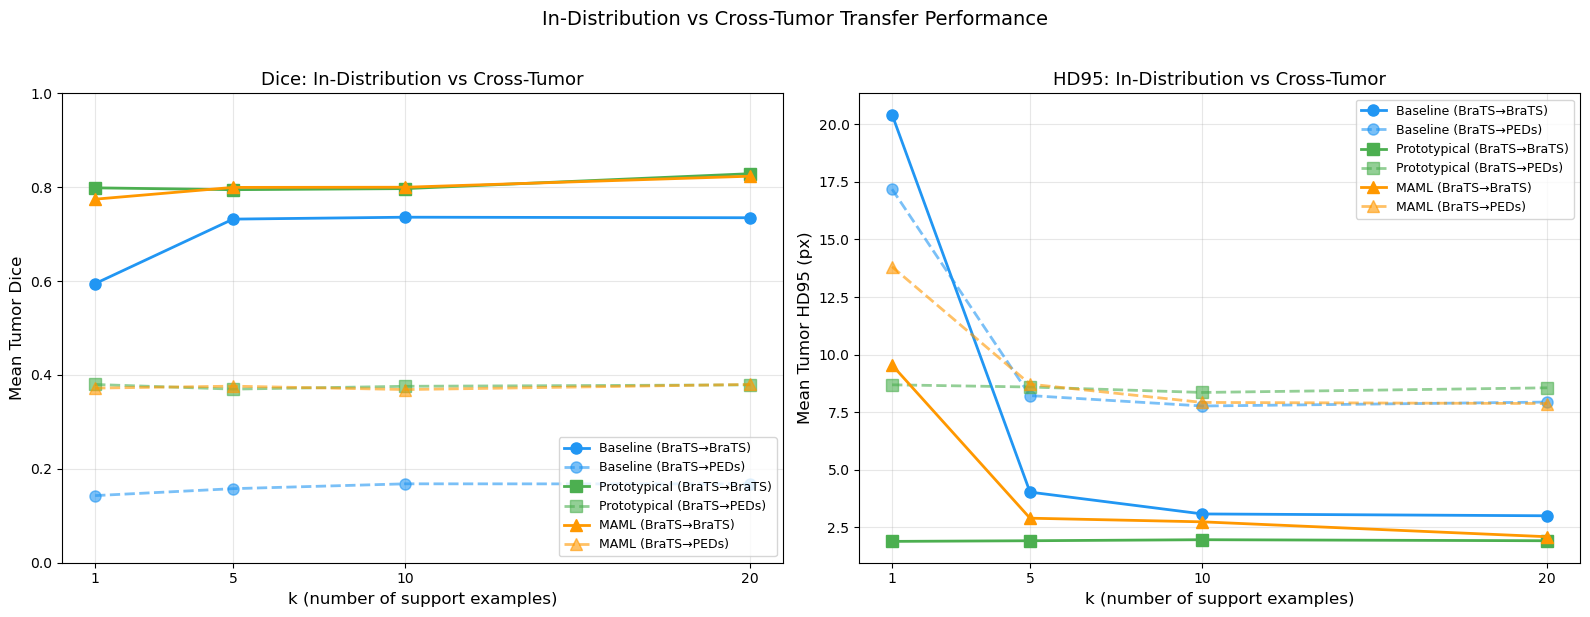

In [20]:
# CELL 13: Comparison Chart — In-Dist vs Cross-Tumor
k_values = Config.K_SHOT_VALUES
 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
 
methods = [
    ('Baseline', baseline_orig, baseline_cross, '#2196F3', 'o'),
    ('Prototypical', proto_orig, proto_cross, '#4CAF50', 's'),
    ('MAML', maml_orig, maml_cross, '#FF9800', '^'),
]
 
# Dice comparison
for name, orig, cross, color, marker in methods:
    if orig is None:
        continue
    orig_means = [orig[str(k)]['mean'] for k in k_values]
    cross_means = [cross[k]['mean'] for k in k_values]
    ax1.plot(k_values, orig_means, marker=marker, color=color,
             linestyle='-', linewidth=2, markersize=8,
             label=f'{name} (BraTS→BraTS)')
    ax1.plot(k_values, cross_means, marker=marker, color=color,
             linestyle='--', linewidth=2, markersize=8, alpha=0.6,
             label=f'{name} (BraTS→PEDs)')
 
ax1.set_xlabel('k (number of support examples)', fontsize=12)
ax1.set_ylabel('Mean Tumor Dice', fontsize=12)
ax1.set_title('Dice: In-Distribution vs Cross-Tumor', fontsize=13)
ax1.set_xticks(k_values)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)
ax1.legend(fontsize=9)
 
# HD95 comparison
for name, orig, cross, color, marker in methods:
    if orig is not None and 'hd95_mean' in orig[str(k_values[0])]:
        orig_hd = [orig[str(k)]['hd95_mean'] for k in k_values]
        ax2.plot(k_values, orig_hd, marker=marker, color=color,
                 linestyle='-', linewidth=2, markersize=8,
                 label=f'{name} (BraTS→BraTS)')
    cross_hd = [cross[k]['hd95_mean'] for k in k_values]
    ax2.plot(k_values, cross_hd, marker=marker, color=color,
             linestyle='--', linewidth=2, markersize=8, alpha=0.6,
             label=f'{name} (BraTS→PEDs)')
 
ax2.set_xlabel('k (number of support examples)', fontsize=12)
ax2.set_ylabel('Mean Tumor HD95 (px)', fontsize=12)
ax2.set_title('HD95: In-Distribution vs Cross-Tumor', fontsize=13)
ax2.set_xticks(k_values)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)
 
plt.suptitle('In-Distribution vs Cross-Tumor Transfer Performance',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'cross_tumor_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# CELL 14: Performance Drop Analysis
if baseline_orig and proto_orig and maml_orig:
    print("\n" + "=" * 75)
    print("PERFORMANCE DROP: In-Distribution → Cross-Tumor")
    print("=" * 75)
 
    # Dice drop
    print(f"\nDICE DROP (negative = worse on pediatric):")
    print(f"{'Method':<25} {'k=1':<12} {'k=5':<12} {'k=10':<12} {'k=20':<12}")
    print(f"{'-'*75}")
    for name, orig, cross in [
        ('Baseline', baseline_orig, baseline_cross),
        ('Prototypical', proto_orig, proto_cross),
        ('MAML', maml_orig, maml_cross),
    ]:
        row = f"{name:<25}"
        for k in Config.K_SHOT_VALUES:
            orig_dice = orig[str(k)]['mean']
            cross_dice = cross[k]['mean']
            delta = cross_dice - orig_dice
            row += f" {delta:+.4f}     "
        print(row)
 
    # HD95 change
    has_hd95 = 'hd95_mean' in baseline_orig[str(k_values[0])]
    if has_hd95:
        print(f"\nHD95 CHANGE (positive = worse boundaries on pediatric):")
        print(f"{'Method':<25} {'k=1':<12} {'k=5':<12} {'k=10':<12} {'k=20':<12}")
        print(f"{'-'*75}")
        for name, orig, cross in [
            ('Baseline', baseline_orig, baseline_cross),
            ('Prototypical', proto_orig, proto_cross),
            ('MAML', maml_orig, maml_cross),
        ]:
            row = f"{name:<25}"
            for k in Config.K_SHOT_VALUES:
                orig_hd = orig[str(k)]['hd95_mean']
                cross_hd = cross[k]['hd95_mean']
                delta = cross_hd - orig_hd
                row += f" {delta:+.1f}px     "
            print(row)
 
    print(f"\n{'='*75}")
    print("Interpretation:")
    print("  Small Dice drop → method generalizes well across tumor types")
    print("  Large Dice drop → method overfit to adult glioblastoma patterns")
    print("  Smaller drop for meta-learning → few-shot adaptation helps OOD")


PERFORMANCE DROP: In-Distribution → Cross-Tumor

DICE DROP (negative = worse on pediatric):
Method                    k=1          k=5          k=10         k=20        
---------------------------------------------------------------------------
Baseline                  -0.4517      -0.5743      -0.5680      -0.5671     
Prototypical              -0.4189      -0.4249      -0.4211      -0.4499     
MAML                      -0.4025      -0.4235      -0.4311      -0.4436     

HD95 CHANGE (positive = worse boundaries on pediatric):
Method                    k=1          k=5          k=10         k=20        
---------------------------------------------------------------------------
Baseline                  -3.2px      +4.2px      +4.7px      +4.9px     
Prototypical              +6.8px      +6.7px      +6.4px      +6.6px     
MAML                      +4.3px      +5.8px      +5.2px      +5.8px     

Interpretation:
  Small Dice drop → method generalizes well across tumor types
  Larg

Generating cross-tumor prediction comparison...


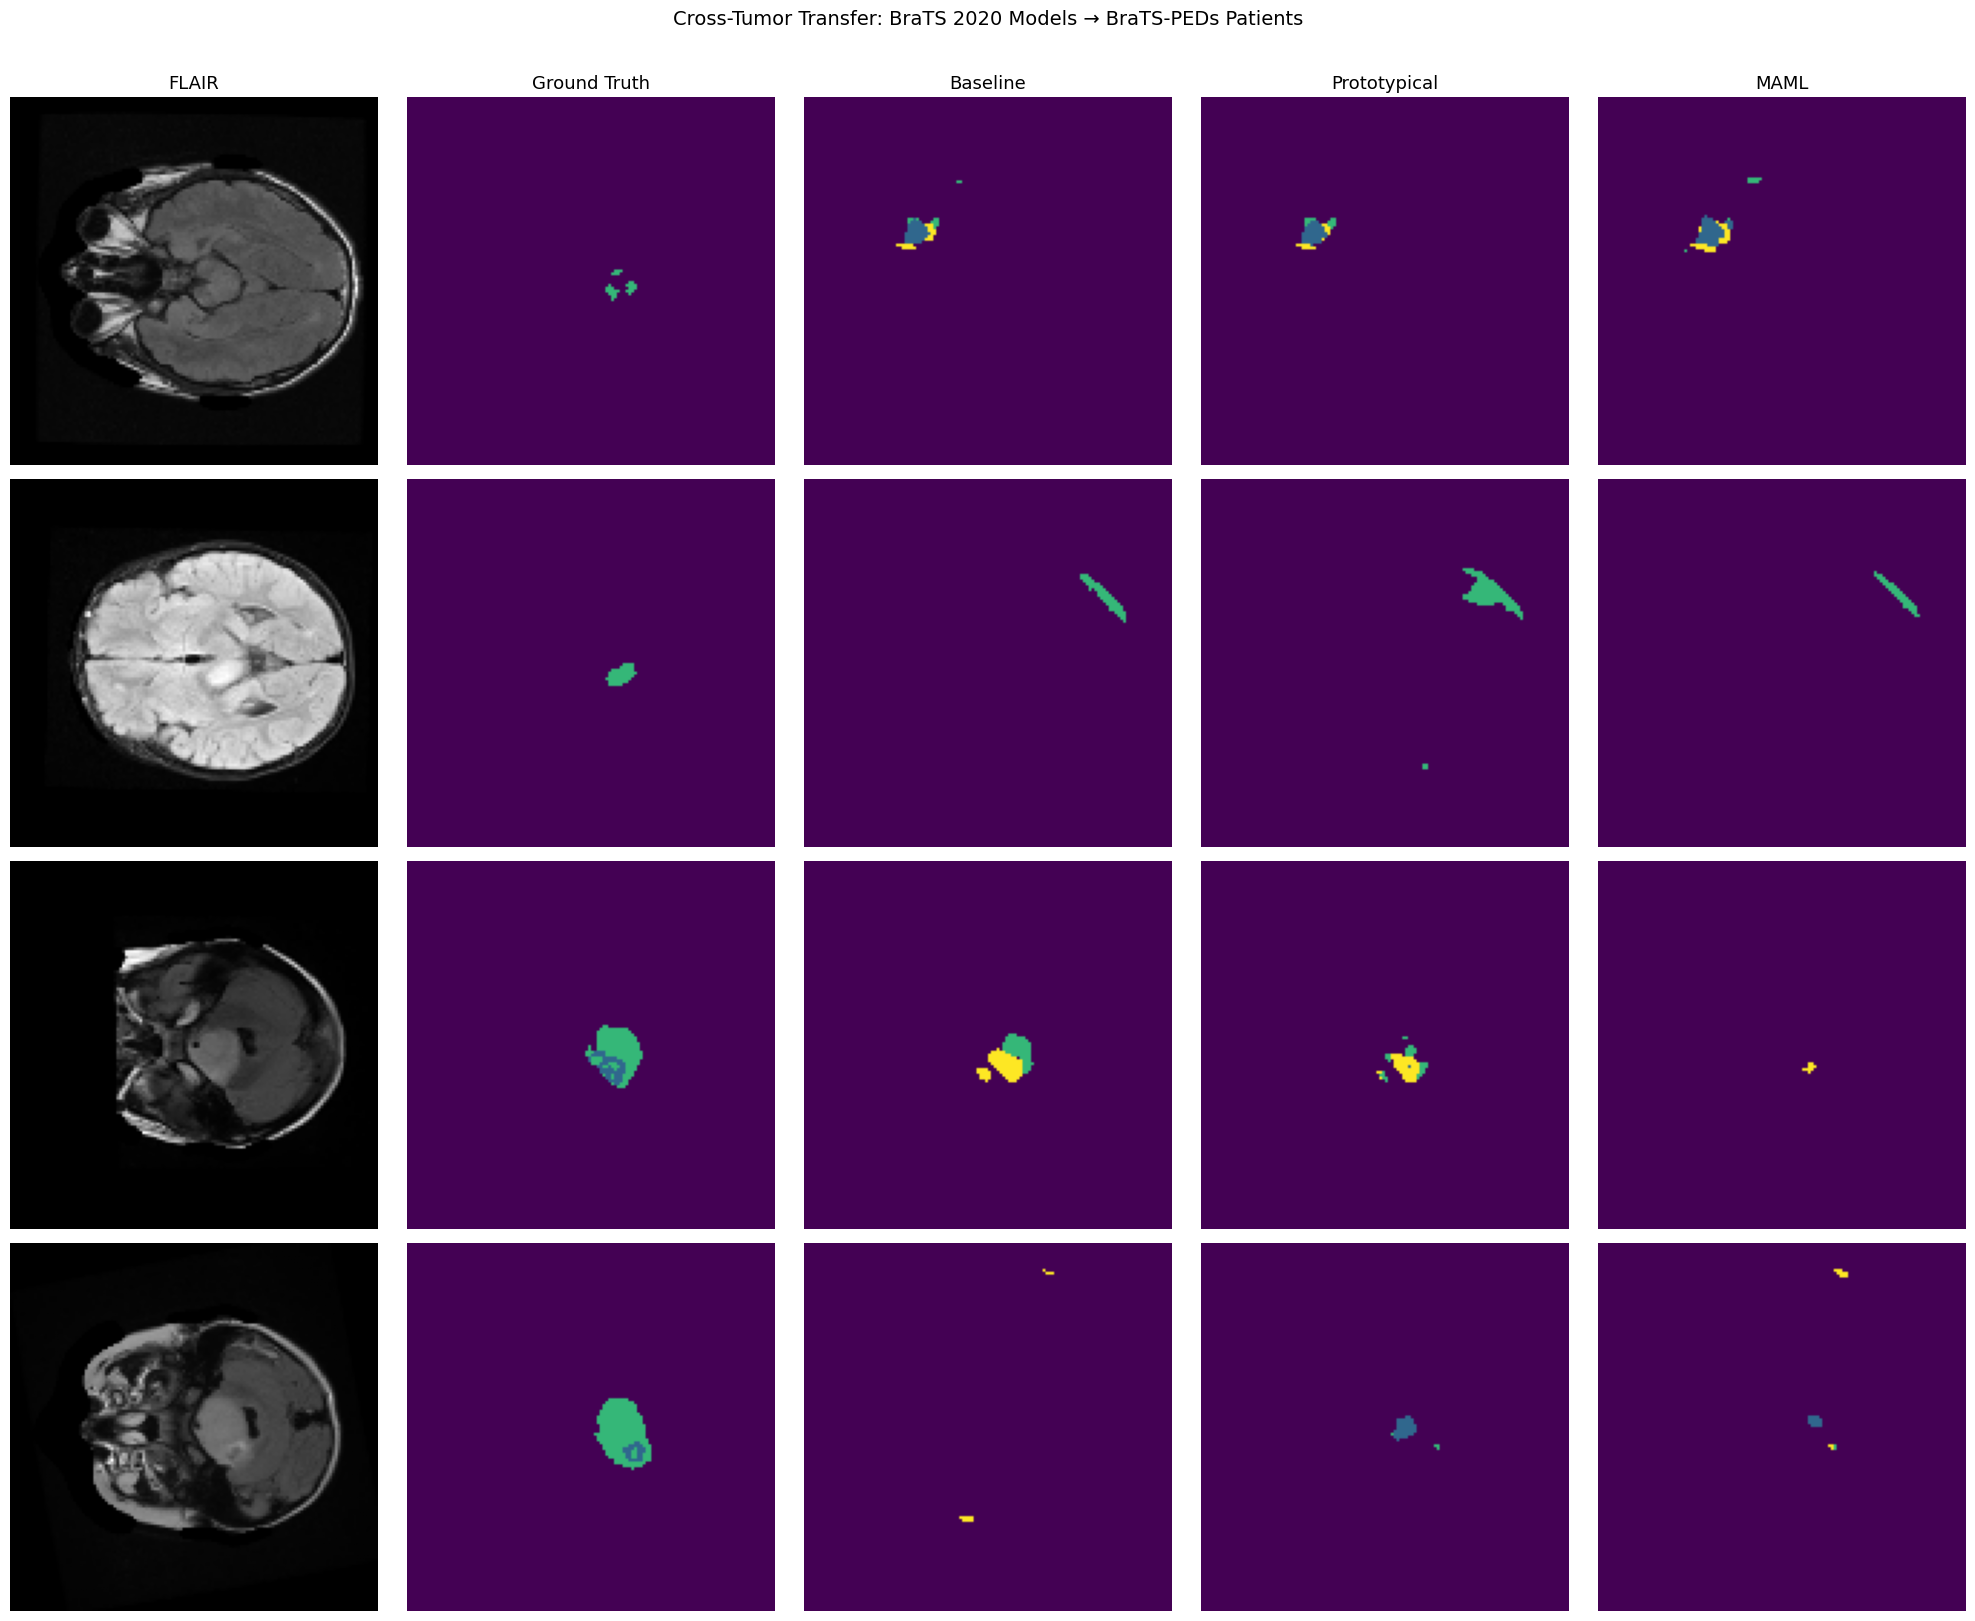

In [22]:
# CELL 15: Qualitative Cross-Tumor Predictions
print("Generating cross-tumor prediction comparison...")
 
sample_indices = random.sample(range(len(peds_index)), 4)
 
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
col_titles = ['FLAIR', 'Ground Truth', 'Baseline', 'Prototypical', 'MAML']
 
for row, idx in enumerate(sample_indices):
    img, mask = peds_index[idx]
    img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(Config.DEVICE)
 
    # FLAIR
    axes[row, 0].imshow(img[0], cmap='gray')
    axes[row, 0].axis('off')
 
    # Ground truth
    axes[row, 1].imshow(mask, cmap='viridis', vmin=0, vmax=3)
    axes[row, 1].axis('off')
 
    # Baseline prediction (no adaptation, just pretrained)
    baseline_model.eval()
    with torch.no_grad():
        pred_b = torch.argmax(baseline_model(img_tensor), dim=1).squeeze().cpu()
    axes[row, 2].imshow(pred_b, cmap='viridis', vmin=0, vmax=3)
    axes[row, 2].axis('off')
 
    # Prototypical prediction (k=5 adult support)
    support_items = random.sample(support_index, 5)
    s_imgs = torch.tensor(np.stack([x[0] for x in support_items]),
                          dtype=torch.float32).to(Config.DEVICE)
    s_masks = torch.tensor(np.stack([x[1] for x in support_items]),
                           dtype=torch.long).to(Config.DEVICE)
    proto_model.eval()
    with torch.no_grad():
        pred_p = proto_model.forward_with_prototype_attention(img_tensor, s_imgs, s_masks)
        pred_p = torch.argmax(pred_p, dim=1).squeeze().cpu()
    axes[row, 3].imshow(pred_p, cmap='viridis', vmin=0, vmax=3)
    axes[row, 3].axis('off')
 
    # MAML prediction (adapt with 5 adult support slices)
    adapted = copy.deepcopy(maml_model.model).to(Config.DEVICE)
    adapted.train()
    adapt_opt = torch.optim.SGD(adapted.parameters(), lr=0.01)
    adapt_loss = smp.losses.DiceLoss(mode='multiclass')
    for _ in range(5):
        adapt_opt.zero_grad()
        loss = adapt_loss(adapted(s_imgs), s_masks)
        loss.backward()
        adapt_opt.step()
    adapted.eval()
    with torch.no_grad():
        pred_m = torch.argmax(adapted(img_tensor), dim=1).squeeze().cpu()
    axes[row, 4].imshow(pred_m, cmap='viridis', vmin=0, vmax=3)
    axes[row, 4].axis('off')
 
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=13)
 
plt.suptitle('Cross-Tumor Transfer: BraTS 2020 Models → BraTS-PEDs Patients',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'cross_tumor_predictions.png'),
            dpi=150, bbox_inches='tight')
plt.show()